In [89]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os

In [90]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [91]:
train_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [92]:
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
train_path = os.path.join(path, "PlantVillage","train")

print("Train path:", train_path)

Using Colab cache for faster access to the 'plantvillage' dataset.
Train path: /kaggle/input/plantvillage/PlantVillage/train


In [93]:
import os

print(os.listdir(train_path))

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___Leaf_Mold', 'Tomato__

In [94]:
train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=(IMG_SIZE,IMG_SIZE),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='categorical',
                                                    subset='training')

Found 34771 images belonging to 38 classes.


In [95]:
val_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=(IMG_SIZE,IMG_SIZE),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='categorical',
                                                    subset='validation')

Found 8673 images belonging to 38 classes.


In [96]:
class_indices = train_generator.class_indices

class_names = list(class_indices.keys())
print("Class indices:", class_indices)
print("Class names:", class_names)

Class indices: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_bligh

In [105]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(512,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(38,activation='softmax')
])

In [106]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,212,006 (12.25 MB)

 Trainable params: 3,212,006 (12.25 MB)

 Non-trainable params: 0 (0.00 B)

In [107]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [109]:
model.fit(train_generator,validation_data=val_generator,epochs=15)

Epoch 1/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 182s 167ms/step - accuracy: 0.4924 - loss: 1.8140 - val_accuracy: 0.7338 - val_loss: 0.8554
Epoch 2/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 100s 92ms/step - accuracy: 0.7980 - loss: 0.6396 - val_accuracy: 0.8503 - val_loss: 0.4745
Epoch 3/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 100s 92ms/step - accuracy: 0.8790 - loss: 0.3770 - val_accuracy: 0.8757 - val_loss: 0.3860
Epoch 4/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 105s 96ms/step - accuracy: 0.9128 - loss: 0.2648 - val_accuracy: 0.9031 - val_loss: 0.3150
Epoch 5/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 101s 93ms/step - accuracy: 0.9361 - loss: 0.1917 - val_accuracy: 0.9059 - val_loss: 0.3310
Epoch 6/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 100s 92ms/step - accuracy: 0.9464 - loss: 0.1573 - val_accuracy: 0.9102 - val_loss: 0.3011
Epoch 7/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 98s 90ms/step - accuracy: 0.9564 - loss: 0.1299 - val_accuracy: 0.9076 - val_loss: 0.3407
Epoch 8/15
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 99s 91ms/step - accuracy: 0

In [110]:
model.save('Plant_Classification.h5')

In [111]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model('Plant_Classification.h5')
print("Model Loaded")

Model Loaded


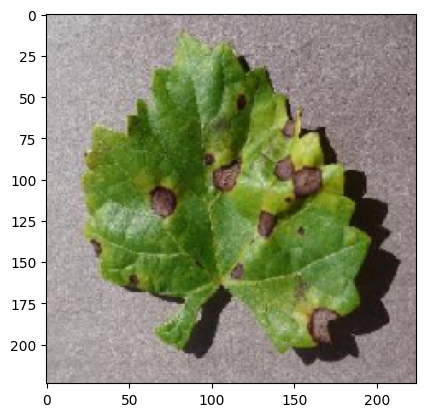

In [120]:
from matplotlib import pyplot as plt
test_image_path = r"/content/Grape.png"
img = image.load_img(test_image_path, target_size=(224, 224))
plt.imshow(img)
plt.axis()
plt.show()

In [121]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

In [122]:
prediction = model.predict(img_array) # Print the prediction
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[1.6882566e-16 1.8659108e-14 5.4879459e-20 1.1816699e-20 3.2384685e-26
  3.7773336e-21 7.6235033e-20 3.0907701e-18 2.1213852e-19 1.7457823e-20
  1.7340488e-26 1.0000000e+00 3.7734477e-12 1.9455768e-10 1.7873583e-10
  3.5056908e-21 1.5051496e-10 2.4700166e-29 2.5674913e-13 6.3521804e-20
  1.4105599e-22 1.3573318e-19 6.1767071e-23 1.6119383e-20 1.9294598e-26
  2.3727009e-15 1.1284835e-18 2.0769761e-19 3.1604242e-17 8.0420576e-10
  6.6633781e-13 1.3113436e-17 3.4889838e-12 1.0409068e-23 1.4936238e-11
  4.2568873e-18 1.2171068e-29 1.2963634e-31]]


In [123]:
prediction = model.predict(img_array)
ind = np.argmax(prediction[0 ])
print (class_names[ind])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Grape___Black_rot
